# Inria Model
Semantic segmentation on Inria Aerial Image Labeling Dataset

Restart kernel after running because takes a lot of memory

Sep 17th-19th 2025

Sep 01st 2026: Larger patch size 256x256 vs. 64x64  
Sep 02nd 2026: 10 epochs, generalize plots to P*P patches  
Sep 03rd 2026: Patch size 1024x1024, other code improvements

## Setup

In [1]:
# Works in VS Code .venv Python 3.11.7

%pip install torchgeo==0.7.1 tensorboard


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import tempfile

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from torchgeo.datamodules import InriaAerialImageLabelingDataModule
from torchgeo.trainers import SemanticSegmentationTask

/Users/nball/Common/Geo/sandbox/torchgeo/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%load_ext tensorboard

In [4]:
# Settings used in more than one place in the notebook

# Directories
data_dir='/Users/nball/Data/Geo/TorchGeo' # Note not /AerialImageDataset/
experiments_dir = Path(tempfile.gettempdir()) / 'Inria' # Logs, checkpoints sent to default names in /tmp

# Non-full runs
frac_subsample = 1.0 # Data subsample for faster runs but not fast_dev_run
fast_dev_run = False # Can be True for one batch of train/val/test, n for n batches, or False

# Training
patch_size = 1024 # Default is 64, larger is better for building segmentation to capture, e.g., roads neq building shape

In [5]:
experiments_dir

PosixPath('/var/folders/mk/yv4n4y352jj7xwf2y_mg5s_00000gn/T/Inria')

## Task

In [6]:
# UNet decoder is default, backbone resnet50 CNN
# Cf. https://github.com/torchgeo/torchgeo?tab=readme-ov-file#reproducibility-with-lightning
# TorchGeo source: https://github.com/torchgeo/torchgeo/blob/main/torchgeo/trainers/segmentation.py

task = SemanticSegmentationTask( # In TorchGeo 0.10.0+ this becomes SemanticSegmentation
    model='unet',
    backbone='resnet50',
    weights=True,
    in_channels=3,
    task='binary',
    loss='bce', # TorchGeo 0.9+ adds pos_weight and Dice loss, but outputs different preds structure; 0.10.0 has bug that breaks the Inria plot method for the data
    freeze_backbone=True,
    lr=0.001 # Default learning rate is 0.001
)

task

SemanticSegmentationTask(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (r

## Data module

In [ ]:
# TorchGeo docs

# https://torchgeo.readthedocs.io/en/stable/api/datamodules.html#inria-aerial-image-labeling
# https://torchgeo.readthedocs.io/en/stable/api/datamodules.html#nongeodatamodule

# TorchGeo sources

# https://github.com/torchgeo/torchgeo/blob/main/torchgeo/datamodules/inria.py
# https://github.com/torchgeo/torchgeo/blob/main/torchgeo/datasets/inria.py
# https://github.com/torchgeo/torchgeo/blob/main/torchgeo/datamodules/geo.py

datamodule = InriaAerialImageLabelingDataModule(
    batch_size=1, # 2+ gives error in tensor sizes; 8+ goes out of memory on M3 laptop
    patch_size=patch_size,
    num_workers=2, # May be able to increase, but no obvious benefit of >> 1
    root=data_dir
)

datamodule

## Trainer

In [8]:
# Mostly default args, e.g., dirs, filenames

logger = TensorBoardLogger(
    save_dir=experiments_dir, 
    name='inria_logs'
)

logger

In [9]:
# Checkpoint and early stopping callbacks based on validation loss
# Cf. https://docs.torchgeo.org/en/v0.7.1/tutorials/trainers.html

checkpoint_callback = ModelCheckpoint(
    monitor='val_loss', # Another option is val_BinaryJaccardIndex to monitor IoU instead of loss; mode would change from min to max
    dirpath=experiments_dir,
    save_top_k=1, # Save top k best models, k=1 in this case
    save_last=True, # Saves a last checkpoint copy as last.ckpt
    mode='min' # Minimize the monitored quantity (val_loss)
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    min_delta=0.0,
    patience=10, # Inactive with a training run of <= 10 epochs and the default one check per epoch
    mode='min',
    strict=True, # Raise an error if the monitored quantity is not found
    check_finite=True # Raise an error if the monitored quantity is not finite
)

In [10]:
# Trainer API: https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.trainer.trainer.Trainer.html

trainer = Trainer(
    accelerator='auto', # Can see gpu or mps on Mac
    callbacks=[checkpoint_callback, early_stopping_callback],
    default_root_dir=experiments_dir,
    fast_dev_run=fast_dev_run,
    max_epochs = 20, # 10 limits runtime to a few minutes for convenience
    limit_train_batches=frac_subsample,
    limit_val_batches=frac_subsample,
    limit_test_batches=frac_subsample,
    limit_predict_batches=frac_subsample,
    log_every_n_steps=1,
    logger=logger
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(limit_train_batches=1.0)` was configured so 100% of the batches per epoch will be used..
`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
`Trainer(limit_test_batches=1.0)` was configured so 100% of the batches will be used..
`Trainer(limit_predict_batches=1.0)` was configured so 100% of the batches will be used..


## Run training

In [29]:
%tensorboard --logdir "$experiments_dir"

Reusing TensorBoard on port 6006 (pid 20378), started 23:21:26 ago. (Use '!kill 20378' to kill it.)

In [12]:
# Takes a few minutes

trainer.fit(model=task, datamodule=datamodule)

/Users/nball/Common/Geo/sandbox/torchgeo/.venv/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /private/var/folders/mk/yv4n4y352jj7xwf2y_mg5s_00000gn/T/Inria exists and is not empty.

  | Name          | Type              | Params | Mode 
------------------------------------------------------------
0 | model         | Unet              | 32.5 M | train
1 | criterion     | BCEWithLogitsLoss | 0      | train
2 | train_metrics | MetricCollection  | 0      | train
3 | val_metrics   | MetricCollection  | 0      | train
4 | test_metrics  | MetricCollection  | 0      | train
------------------------------------------------------------
9.0 M     Trainable params
23.5 M    Non-trainable params
32.5 M    Total params
130.084   Total estimated model params size (MB)
233       Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/nball/Common/Geo/sandbox/torchgeo/.venv/lib/python3.11/site-packages/kornia/contrib/extract_patches.py:485: UserWarning: The window will not fit into the image. 
Window size: (1024, 1024)
Stride: (1024, 1024)
Image size: (5000, 5000)
This means that the final incomplete patches will be dropped. By enabling `allow_auto_padding`, the input will be padded to fit the window and stride.
  warn(


Epoch 16: 100%|██████████| 155/155 [01:18<00:00,  1.99it/s, v_num=11]      


## Run validation

In [13]:
# Takes a few minutes

results_val = trainer.validate(model=task, datamodule=datamodule)

Validation DataLoader 0: 100%|██████████| 25/25 [00:38<00:00,  0.65it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    val_BinaryAccuracy     │    0.9272911548614502     │
│  val_BinaryJaccardIndex   │    0.5293229818344116     │
│         val_loss          │    0.19457601010799408    │
└───────────────────────────┴───────────────────────────┘

In [14]:
results_val

[{'val_BinaryAccuracy': 0.9272911548614502,
  'val_BinaryJaccardIndex': 0.5293229818344116,
  'val_loss': 0.19457601010799408}]

## Run predictions

In [15]:
# Takes a few minutes

preds = trainer.predict(model=task, datamodule=datamodule)

Predicting DataLoader 0: 100%|██████████| 180/180 [03:47<00:00,  0.79it/s]


In [16]:
len(preds) # 180 for full dataset, 18 for frac_subsample=0.1

180

In [17]:
preds

[tensor([[[[0.2133, 0.0870, 0.0842,  ..., 0.1125, 0.1258, 0.2052],
           [0.0884, 0.0213, 0.0199,  ..., 0.0349, 0.0449, 0.1286],
           [0.0702, 0.0143, 0.0137,  ..., 0.0267, 0.0360, 0.1177],
           ...,
           [0.0569, 0.0090, 0.0067,  ..., 0.0155, 0.0242, 0.0982],
           [0.0670, 0.0123, 0.0091,  ..., 0.0213, 0.0294, 0.1053],
           [0.1381, 0.0491, 0.0409,  ..., 0.0717, 0.0873, 0.1895]]],
 
 
         [[[0.2207, 0.1042, 0.1071,  ..., 0.0719, 0.0819, 0.1571],
           [0.1078, 0.0351, 0.0390,  ..., 0.0180, 0.0231, 0.0825],
           [0.0975, 0.0284, 0.0283,  ..., 0.0135, 0.0179, 0.0736],
           ...,
           [0.0564, 0.0091, 0.0068,  ..., 0.0221, 0.0341, 0.1120],
           [0.0660, 0.0122, 0.0092,  ..., 0.0336, 0.0394, 0.1146],
           [0.1359, 0.0487, 0.0412,  ..., 0.0996, 0.1075, 0.2051]]],
 
 
         [[[0.2285, 0.0986, 0.0880,  ..., 0.0997, 0.1187, 0.1943],
           [0.1118, 0.0308, 0.0259,  ..., 0.0266, 0.0367, 0.1192],
           [0.0987

## Plot predictions

In [18]:
# P by P patches in 5000 by 5000 image, e.g., 78 by 78 = 6084 64^2 patches fit in 5000 by 5000 image with fractional edge after 78*64 removed
# preds[N] is the set of predictions for image N in the datamodule.predict_dataset
# Want to combine them into one image and plot alongside the predict_dataset image

n_patches = preds[0].shape[0] # No. predictions is number of patches
np_idx = n_patches - 1
np_dim = int(np.sqrt(n_patches)) # Assuming the patches form a square grid

print(n_patches)
print(np_dim)
print(np_idx)

print(preds[0].shape)
print(preds[1].shape)
#etc.

print(preds[0][np_idx].shape)

16
4
15
torch.Size([16, 1, 1024, 1024])
torch.Size([16, 1, 1024, 1024])
torch.Size([1, 1024, 1024])


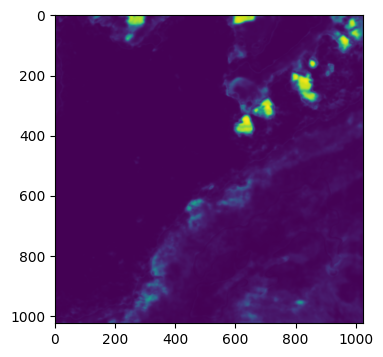

In [19]:
# Plot one of the predictions from preds
image = preds[0][np_idx].squeeze().cpu().numpy()
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
ax.imshow(image)

In [20]:
image

array([[0.2136445 , 0.0912181 , 0.08303101, ..., 0.16999312, 0.1766034 ,
        0.24362667],
       [0.0942135 , 0.02644078, 0.02493327, ..., 0.08008304, 0.08394368,
        0.17008206],
       [0.0792169 , 0.02114387, 0.02268894, ..., 0.07946681, 0.08042767,
        0.1688379 ],
       ...,
       [0.07731124, 0.01596006, 0.01363389, ..., 0.02738717, 0.03088007,
        0.09661775],
       [0.08849431, 0.02041272, 0.01718115, ..., 0.02975282, 0.03338986,
        0.10021508],
       [0.16300726, 0.06558553, 0.0588083 , ..., 0.07857284, 0.08823562,
        0.1852108 ]], shape=(1024, 1024), dtype=float32)

In [ ]:
# Data is ordered by filename rather than city names

# Train

# Area                  No. images   Indices   Filename

# Austin, TX            31           0-30      austin
# Chicago, IL           31           31-61     chicago
# Kitsap county, WA     31           62-92     kitsap
# West Tyrol, Austria   31           93-123    tyrol-w
# Vienna, Austria       31           124-154   vienna

# Validation: First 5 images of each area in training dataset

# Area                  No. images   Indices   Filename

# Austin, TX            5            0-4       austin
# Chicago, IL           5            5-9       chicago
# Kitsap county, WA     5            10-14     kitsap
# West Tyrol, Austria   5            15-19     tyrol-w
# Vienna, Austria       5            20-24     vienna

# Test

# Area                  No. images   Indices   Filename

# Bellingham, WA        36           0-35      bellingham
# Bloomington, IN       36           36-71     bloomington
# Innsbruck, Austria    36           72-107    innsbruck
# San Francisco, CA     36           108-143   sfo
# East Tyrol, Austria   36           144-179   tyrol-e

In [41]:
# Index of image in preds to combine: choose one from zero to len(preds)-1, e.g., 0-179 for test set
# Then run this cell + below

N = 144

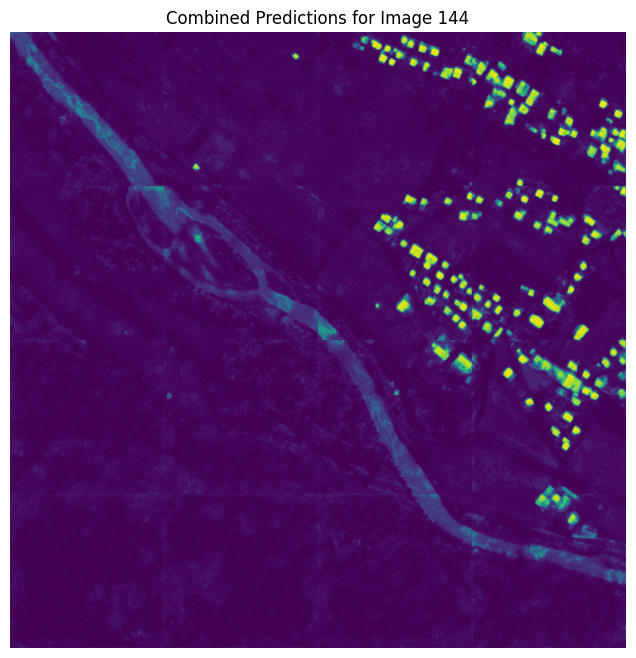

In [42]:
# Combine the n_patches patches in preds[N] into one image
# (AI code, modified)

def combine_patches(patches, grid_size=(np_dim, np_dim), patch_size=(patch_size, patch_size)):
    combined_image = np.zeros((grid_size[0] * patch_size[0], grid_size[1] * patch_size[1]))
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            combined_image[i * patch_size[0]:(i + 1) * patch_size[0],
                           j * patch_size[1]:(j + 1) * patch_size[1]] = patches[i * grid_size[1] + j].squeeze().cpu().numpy()
    return combined_image

combined_image = combine_patches(preds[N])
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))
ax.imshow(combined_image)
ax.set_title('Combined Predictions for Image {}'.format(N))
ax.axis('off')
plt.show()

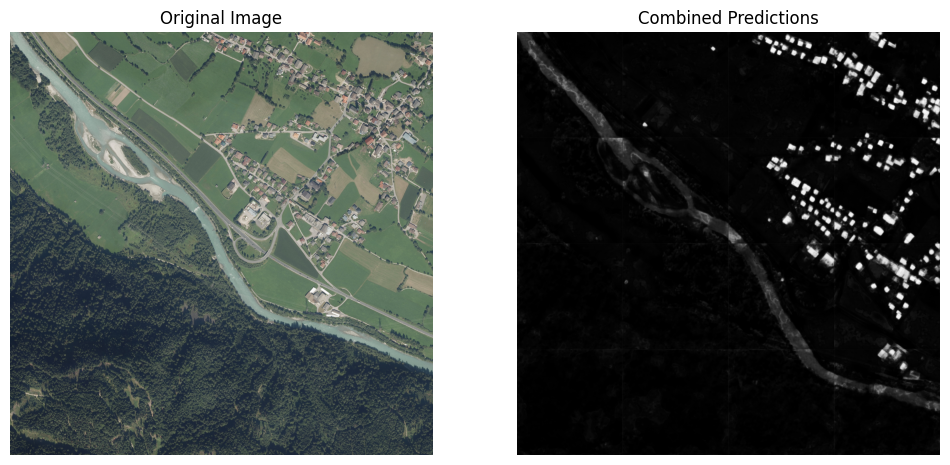

In [ ]:
# Plot combined_image from the patches in preds[N] above alongside the corresponding original image from the prediction dataset
# (AI code with uint8 typing added, modified [0] to [N])

sample = datamodule.predict_dataset[N]
image = sample['image'].squeeze().cpu().numpy().astype(np.uint8)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

axs[0].imshow(image.transpose(1, 2, 0)) # Image shape is (3, 5000, 5000), need to transpose to (5000, 5000, 3) for plt.imshow
axs[0].set_title('Original Image')
axs[0].axis('off')

axs[1].imshow(combined_image, cmap='gray')
axs[1].set_title('Combined Predictions')
axs[1].axis('off')

plt.show()

In [44]:
image

array([[[134, 141, 145, ..., 118, 121, 127],
        [141, 144, 144, ..., 142, 129, 121],
        [138, 138, 139, ..., 179, 164, 148],
        ...,
        [ 51,  39,  43, ...,  91,  80,  74],
        [ 77,  60,  69, ...,  94,  94, 100],
        [ 81,  78,  97, ...,  79,  64,  82]],

       [[154, 161, 165, ..., 115, 120, 126],
        [161, 164, 164, ..., 138, 127, 119],
        [158, 158, 159, ..., 175, 162, 146],
        ...,
        [ 60,  48,  52, ..., 102,  91,  85],
        [ 86,  69,  78, ..., 106, 105, 111],
        [ 92,  89, 107, ...,  91,  75,  93]],

       [[145, 152, 156, ..., 100, 102, 108],
        [152, 155, 155, ..., 126, 112, 104],
        [149, 149, 150, ..., 164, 150, 134],
        ...,
        [ 55,  45,  49, ...,  94,  83,  77],
        [ 83,  66,  75, ...,  96,  97, 103],
        [ 88,  85, 106, ...,  81,  67,  85]]],
      shape=(3, 5000, 5000), dtype=uint8)